In [1]:
import pandas as pd 
from scipy.sparse import csr_matrix

import pandas as pd                                                                                                             
import numpy as np                                                                                                            
from scipy import sparse                                                                                                        
from itertools import pairwise
import anndata as ad 
import mudata as md 

In [2]:
def get_unique_mappings(psm_table: pd.DataFrame, feature_level_names: list[str]) -> pd.DataFrame:
    """Get all unique mappings"""
    return psm_subset.loc[:, levels].drop_duplicates(subset=levels)
    

def adjacency_matrix_from_mapping(df: pd.DataFrame) -> pd.DataFrame:                                                            
    """Convert a mapping DataFrame to a sparse undirected adjacency matrix.                                                     
                                                                                                                                
    Each row creates edges between values in consecutive columns,                                                               
    representing hierarchical relationships.                                                   
    """                                                                                                                         
    all_values = pd.unique(df.values.ravel())                                                                                   
    value_to_idx = {v: i for i, v in enumerate(all_values)}                                                                     
    n = len(all_values)                                                                                                         
                                                                                                                                
    rows, cols = [], []                                                                                                         
    for _, row in df.iterrows():                                                                                                
        for v1, v2 in pairwise(row.values):                                                                                     
            i, j = value_to_idx[v1], value_to_idx[v2]                                                                           
            rows.extend([i, j])                                                                                                 
            cols.extend([j, i])                                                                                                 
                                                                                                                                
    adj = sparse.coo_matrix(                                                                                                    
        (np.ones(len(rows), dtype=np.float64), (rows, cols)),
        shape=(n, n),                                                                                                           
    ).tocsr()                                                                                                                     
    adj.data = np.ones_like(adj.data)  # collapse summed duplicates to 1                                                                                                                        
    return pd.DataFrame.sparse.from_spmatrix(adj, index=all_values, columns=all_values)     



# EXAMPLE DATA 
# Manually create a mapping and example data
var = pd.DataFrame(
    {
    "genes": [*(["gene0", "gene1", "gene1"]*2)], 
    "proteins": [*(["protein0", "protein1", "protein2"]*2)], 
    "precursors": [str(idx) for idx in range(1, 7)]
    },
    index=[str(idx) for idx in range(1, 7)]

)

levels = ["genes", "proteins", "precursors"]

psm_subset = pd.concat({"A": var, "B": var}).reset_index(level=0, names="sample")


precursors = ad.AnnData(
    X=np.zeros(shape=(5, 6)),
    obs=pd.DataFrame(index=[f"sample{idx}" for idx in range(5)]),
    var=var
)

proteins = ad.AnnData(
    X=np.zeros(shape=(5, 3)),
    obs=pd.DataFrame(index=[f"sample{idx}" for idx in range(5)]),
    var=pd.DataFrame(
        data={
            "proteins": ["protein0", "protein1", "protein2"],
            "genes": ["gene0", "gene1", "gene1"]
            },
        index=["protein0", "protein1", "protein2"])
)

genes = ad.AnnData(
    X=np.zeros(shape=(5, 2)),
    obs=pd.DataFrame(index=[f"sample{idx}" for idx in range(5)]),
    var=pd.DataFrame(index=["gene0", "gene1"])
)


# Create MUDATA (from manual dataset)
df = get_unique_mappings(psm_subset, feature_level_names=levels)
adjaceny = adjacency_matrix_from_mapping(df).sort_index(axis=0).sort_index(axis=1)


mdata = md.MuData(
    data={"precursors": precursors, "proteins": proteins, "genes": genes},
)
# Ensure that index ordering is correct
mdata.varp["feature_mapping"] = adjaceny.reindex(index=mdata.var_names, columns=mdata.var_names)

mdata

/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 5 × 11
  varp:	'feature_mapping'
  3 modalities
    precursors:	5 x 6
      var:	'genes', 'proteins', 'precursors'
    proteins:	5 x 3
      var:	'proteins', 'genes'
    genes:	5 x 2

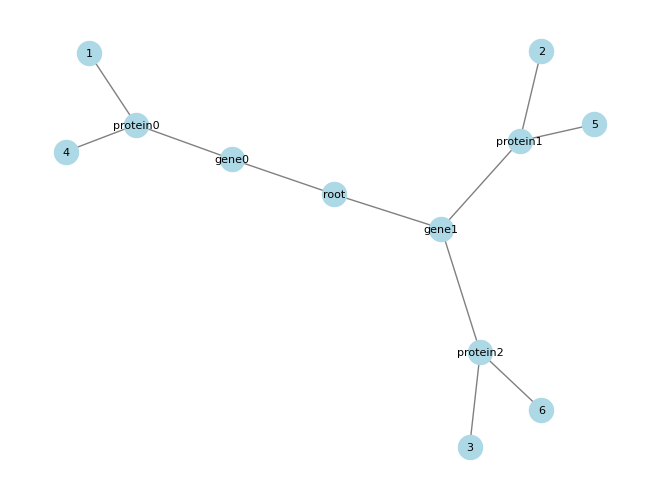

In [3]:
import networkx as nx                                                                                                           
import matplotlib.pyplot as plt                                                                                               
                                                                                                                                  
G = nx.from_pandas_adjacency(adjaceny)         
G.add_node("root") 
G.add_edge(*("root", "gene0"))         
G.add_edge(*("root", "gene1"))                                                                                   

# Relabel nodes from integer indices back to feature names                                                                      
# layout = nx.bipartite_layout(G, nodes={"level0": "root", "level1": ["gene0", "gene1"], "level2": ["protein0", "protein1", "protein2"], "level3": [str(idx) for idx in range(7)]})                                                                                                                             
nx.draw(G, with_labels=True, node_color="lightblue", edge_color="gray", font_size=8)                                            
plt.show()   

In [4]:
mdata.write_zarr("minimal1.h5mu")
mdata.write_h5mu("minimal1.h5mu")

/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


IsADirectoryError: [Errno 21] Unable to synchronously create file (unable to open file: name = 'minimal1.h5mu', errno = 21, error message = 'Is a directory', flags = 13, o_flags = 602)